# Visualizzazione File GRIB Output WRF

Plot di variabili dai file GRIB convertiti da WRF a livelli di pressione

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Stile plot
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Selezione e Caricamento File GRIB

In [17]:
# Directory output
output_dir = Path("/home/lmonaco/CHAPTER/output")

# Lista file GRIB disponibili
grib_files = list(output_dir.glob("*.grib*"))

print("File GRIB disponibili:")
for i, f in enumerate(grib_files):
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {i}: {f.name} ({size_mb:.1f} MB)")

# Seleziona il primo file GRIB1 (o puoi cambiare l'indice)
grib_file = [f for f in grib_files if 'grib' in f.name or 'grib2' in f.name][-1]
print(f"\nFile selezionato: {grib_file.name}")

File GRIB disponibili:
  0: ailam-an-cima-3km-2023-2023-1h-v1-2023032812.grib (927.4 MB)
  1: ailam-an-cima-3km-2023-2023-1h-v1-2023032815.grib (927.4 MB)
  2: ailam-an-cima-3km-2023-2023-1h-v1-2023032812.grib.5b7b6.idx (0.0 MB)
  3: ailam-an-cima-3km-2023-2023-1h-v1-2023032813.grib (927.4 MB)
  4: ailam-an-cima-3km-2023-2023-1h-v1-2023032814.grib (88.9 MB)

File selezionato: ailam-an-cima-3km-2023-2023-1h-v1-2023032814.grib


In [18]:
# Carica il file GRIB con xarray (usando backend cfgrib)
# GRIB può contenere multipli "messages" quindi potrebbe generare multipli dataset
try:
    # Prova a caricare tutti i messaggi insieme
    ds = xr.open_dataset(grib_file, engine='cfgrib')
    print("Dataset caricato con successo!\n")
    print(ds)
except Exception as e:
    print(f"Errore caricamento singolo dataset: {e}")
    print("\nProvo a caricare messaggi separati...")
    
    # Carica ogni tipo di messaggio separatamente
    import cfgrib
    datasets = cfgrib.open_datasets(str(grib_file))
    print(f"\nTrovati {len(datasets)} dataset separati nel file GRIB")
    
    # Usa il primo dataset
    ds = datasets[0]
    print("\nPrimo dataset:")
    print(ds)

Dataset caricato con successo!

<xarray.Dataset> Size: 160MB
Dimensions:            (values: 2220273, isobaricInhPa: 13)
Coordinates:
    latitude           (values) float64 18MB ...
    longitude          (values) float64 18MB ...
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    t2m                (values) float32 9MB ...
    t                  (isobaricInhPa, values) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    his

## 2. Esplorazione Dataset GRIB

In [19]:
print("="*70)
print("VARIABILI DISPONIBILI NEL FILE GRIB")
print("="*70)

print("\nData variables:")
for var_name in ds.data_vars:
    var = ds[var_name]
    print(f"\n{var_name}:")
    print(f"  Dims: {var.dims}")
    print(f"  Shape: {var.shape}")
    print(f"  Units: {var.attrs.get('units', 'N/A')}")
    print(f"  Long name: {var.attrs.get('long_name', 'N/A')}")
    if 'GRIB_paramId' in var.attrs:
        print(f"  GRIB paramId: {var.attrs['GRIB_paramId']}")

print("\n" + "="*70)
print("COORDINATE:")
print("="*70)
for coord_name in ds.coords:
    coord = ds.coords[coord_name]
    print(f"\n{coord_name}: {coord.shape}")
    if coord.size < 20:
        print(f"  Values: {coord.values}")
    else:
        print(f"  Range: {coord.min().values} to {coord.max().values}")

VARIABILI DISPONIBILI NEL FILE GRIB

Data variables:

t2m:
  Dims: ('values',)
  Shape: (2220273,)
  Units: K
  Long name: 2 metre temperature
  GRIB paramId: 167

t:
  Dims: ('isobaricInhPa', 'values')
  Shape: (13, 2220273)
  Units: K
  Long name: Temperature
  GRIB paramId: 130

COORDINATE:

number: ()
  Values: 0

time: ()
  Values: 2023-03-28T14:00:00.000000000

step: ()
  Values: 0 nanoseconds

heightAboveGround: ()
  Values: 2.0

latitude: (2220273,)
  Range: 23.471999999999998 to 60.01082798397588

longitude: (2220273,)
  Range: 0.03228719772718083 to 359.9943283984905

valid_time: ()
  Values: 2023-03-28T14:00:00.000000000

isobaricInhPa: (13,)
  Values: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   50.]


## 3. Plot Variabile Superficie (2D)

In [20]:
# Seleziona una variabile da plottare
# Cerca variabili comuni: temperatura, pressione, vento, umidità
var_names = list(ds.data_vars)
print(f"Variabili disponibili: {var_names}")

# Prendi la prima variabile 2D
var_to_plot = None
for var_name in var_names:
    var = ds[var_name]
    # Cerca variabili con dimensioni lat/lon (2D o 3D con livelli)
    if 'latitude' in var.dims or 'y' in var.dims:
        var_to_plot = var_name
        break

if var_to_plot is None:
    var_to_plot = var_names[0]

var_to_plot="t2m"
print(f"\nPlotting: {var_to_plot}")

Variabili disponibili: ['t2m', 't']

Plotting: t2m


In [21]:
# Estrai la variabile
var_data = ds[var_to_plot]

# Se ha dimensione isobaricInhPa (livelli di pressione), seleziona un livello
if 'isobaricInhPa' in var_data.dims:
    # Prendi il primo livello disponibile
    pressure_levels = var_data.coords['isobaricInhPa'].values
    print(f"Livelli di pressione disponibili: {pressure_levels}")
    selected_level = pressure_levels[0]
    print(f"Selezionato livello: {selected_level} hPa")
    var_data = var_data.sel(isobaricInhPa=selected_level)

# Se ha dimensione time, prendi il primo timestep
if 'time' in var_data.dims:
    var_data = var_data.isel(time=0)

# Se ha step (forecast step), prendi il primo
if 'step' in var_data.dims:
    var_data = var_data.isel(step=0)

print(f"\nDimensioni finali: {var_data.dims}")
print(f"Shape: {var_data.shape}")
print(f"Min: {float(var_data.min()):.4f}")
print(f"Max: {float(var_data.max()):.4f}")
print(f"Mean: {float(var_data.mean()):.4f}")

# DIAGNOSTICA COORDINATE
print("\n" + "="*70)
print("DIAGNOSTICA COORDINATE:")
print("="*70)
if 'latitude' in var_data.coords:
    lats = var_data.coords['latitude'].values
    print(f"Latitude: min={lats.min():.4f}, max={lats.max():.4f}")
if 'longitude' in var_data.coords:
    lons = var_data.coords['longitude'].values
    print(f"Longitude: min={lons.min():.4f}, max={lons.max():.4f}")
    if lons.min() > 180 or lons.max() > 180:
        print("⚠️  Longitude in formato 0-360, verrà convertita a -180-180")

# Controlla proiezione GRIB
print("\nAttributi GRIB:")
for key in ['GRIB_gridType', 'GRIB_projectionCentreFlag', 'GRIB_Nx', 'GRIB_Ny']:
    if key in var_data.attrs:
        print(f"  {key}: {var_data.attrs[key]}")


Dimensioni finali: ('values',)
Shape: (2220273,)
Min: 258.4170
Max: 312.7918
Mean: 286.8836

DIAGNOSTICA COORDINATE:
Latitude: min=23.4720, max=60.0108
Longitude: min=0.0323, max=359.9943
⚠️  Longitude in formato 0-360, verrà convertita a -180-180

Attributi GRIB:
  GRIB_gridType: mercator


GRIB grid type: mercator
Convertendo longitude da 0-360 a -180-180...

Data shape: (2220273,)
Lats shape: (2220273,)
Lons shape: (2220273,)
Lats range: [23.47, 60.01]
Lons range: [-19.97, 42.28]
Usando scatter plot per dati 1D


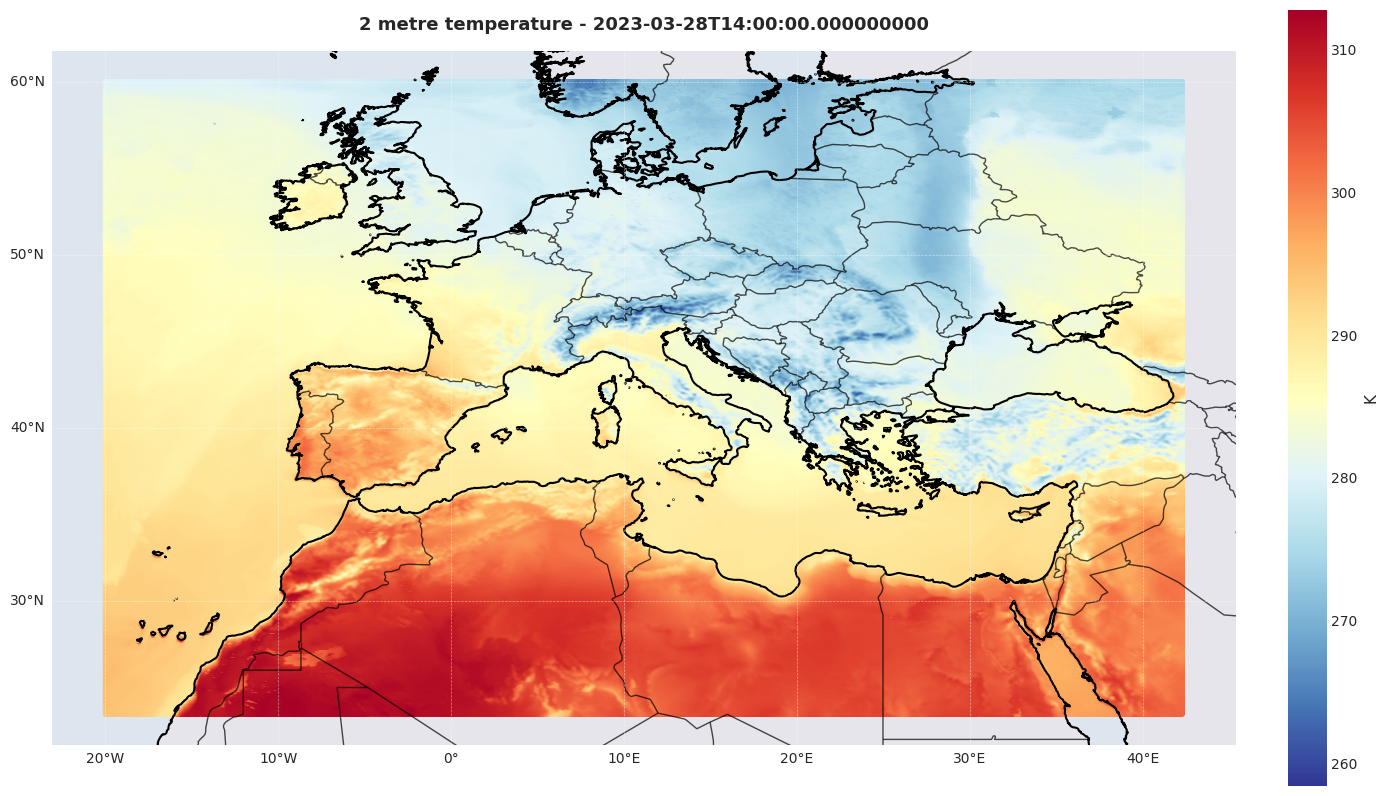

In [22]:
# Plot della variabile su mappa
fig = plt.figure(figsize=(14, 10))

# Determina la proiezione corretta dal GRIB
# WRF usa Lambert Conformal, quindi dobbiamo usare quella proiezione
projection = ccrs.PlateCarree()  # Default

# Controlla se c'è informazione sulla proiezione nel GRIB
if 'GRIB_gridType' in var_data.attrs:
    grid_type = var_data.attrs['GRIB_gridType']
    print(f"GRIB grid type: {grid_type}")
    
    # Se è Lambert Conformal, potremmo provare a estrarre i parametri
    # ma per semplicità useremo PlateCarree per visualizzazione

ax = plt.subplot(1, 1, 1, projection=projection)

# Determina coordinate lat/lon
if 'latitude' in var_data.coords and 'longitude' in var_data.coords:
    lats = var_data.coords['latitude'].values
    lons = var_data.coords['longitude'].values
    
    # CONVERSIONE IMPORTANTE: Se longitude è in formato 0-360, converti a -180-180
    if lons.max() > 180:
        print("Convertendo longitude da 0-360 a -180-180...")
        lons = np.where(lons > 180, lons - 360, lons)
    
elif 'y' in var_data.coords and 'x' in var_data.coords:
    # Coordinate potrebbero essere in griglia proiettata
    lats = var_data.coords['y'].values
    lons = var_data.coords['x'].values
else:
    # Usa dimensioni dirette
    lats = None
    lons = None

# Scelta colormap in base al tipo di variabile
var_name_lower = var_to_plot.lower()
if 't' in var_name_lower or 'temp' in var_name_lower:
    cmap = 'RdYlBu_r'
elif 'wind' in var_name_lower or 'u' in var_name_lower or 'v' in var_name_lower:
    cmap = 'coolwarm'
elif 'pressure' in var_name_lower or 'msl' in var_name_lower or 'sp' in var_name_lower:
    cmap = 'viridis'
elif 'rain' in var_name_lower or 'precip' in var_name_lower:
    cmap = 'Blues'
else:
    cmap = 'viridis'

print(f"\nData shape: {var_data.shape}")
print(f"Lats shape: {lats.shape if lats is not None else 'None'}")
print(f"Lons shape: {lons.shape if lons is not None else 'None'}")
if lats is not None:
    print(f"Lats range: [{lats.min():.2f}, {lats.max():.2f}]")
    print(f"Lons range: [{lons.min():.2f}, {lons.max():.2f}]")

# Plot - IMPORTANTE: specificare sempre transform=ccrs.PlateCarree() per i dati
if lats is not None and lons is not None:
    # Check se dati sono 1D (flattened) o 2D
    if len(var_data.shape) == 1:
        # Dati 1D: usa scatter plot
        print("Usando scatter plot per dati 1D")
        im = ax.scatter(lons, lats, c=var_data.values, cmap=cmap, s=10,
                       transform=ccrs.PlateCarree())
    elif len(lats.shape) == 1 and len(lons.shape) == 1 and len(var_data.shape) == 2:
        # Coordinate 1D e dati 2D - usa pcolormesh
        print("Usando pcolormesh per griglia regolare")
        im = ax.pcolormesh(lons, lats, var_data.values, cmap=cmap, 
                          transform=ccrs.PlateCarree(), shading='auto')
    elif len(lats.shape) == 2 and len(lons.shape) == 2 and len(var_data.shape) == 2:
        # Coordinate 2D e dati 2D
        print("Usando pcolormesh per griglia curvilinea")
        im = ax.pcolormesh(lons, lats, var_data.values, cmap=cmap,
                          transform=ccrs.PlateCarree(), shading='auto')
    else:
        # Fallback: scatter se dimensioni non compatibili
        print(f"Dimensioni non standard, usando scatter plot")
        # Flatten tutto se necessario
        lons_flat = lons.flatten()
        lats_flat = lats.flatten()
        data_flat = var_data.values.flatten()
        im = ax.scatter(lons_flat, lats_flat, c=data_flat, cmap=cmap, s=10,
                       transform=ccrs.PlateCarree())
else:
    # Fallback: imshow senza coordinate
    print("Nessuna coordinata geografica, usando imshow")
    if len(var_data.shape) == 2:
        im = ax.imshow(var_data.values, cmap=cmap, aspect='auto',
                      transform=ccrs.PlateCarree())
    else:
        print(f"⚠️ Non posso plottare dati con shape {var_data.shape}")
        plt.close()
        raise ValueError(f"Dati non plottabili: shape={var_data.shape}")

# Imposta extent geografico basato sui dati
if lats is not None and lons is not None:
    lat_min, lat_max = lats.min(), lats.max()
    lon_min, lon_max = lons.min(), lons.max()
    
    # Aggiungi un piccolo margine
    margin_lat = (lat_max - lat_min) * 0.05
    margin_lon = (lon_max - lon_min) * 0.05
    
    ax.set_extent([lon_min - margin_lon, lon_max + margin_lon,
                   lat_min - margin_lat, lat_max + margin_lat],
                  crs=ccrs.PlateCarree())

# Aggiungi features geografiche
ax.coastlines(resolution='10m', linewidth=1.5, color='black')
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black', alpha=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

# Gridlines con etichette
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
units = var_data.attrs.get('units', '')
cbar.set_label(f'{units}', fontsize=11)

# Title
long_name = var_data.attrs.get('long_name', var_to_plot)
title = f"{long_name}"
if 'isobaricInhPa' in ds[var_to_plot].dims:
    title += f" @ {selected_level} hPa"
if 'time' in ds[var_to_plot].coords:
    time_val = ds[var_to_plot].coords['time'].values
    if hasattr(time_val, '__iter__') and len(time_val) > 0:
        time_val = time_val[0] if len(time_val.shape) > 0 else time_val
    title += f" - {time_val}"

ax.set_title(title, fontsize=13, weight='bold', pad=15)

plt.tight_layout()
plt.show()

## 4. Plot Multiple Variabili (Grid)

ValueError: not enough values to unpack (expected 2, got 1)

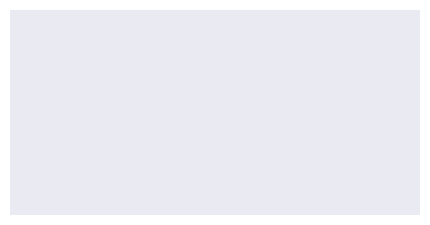

In [23]:
# Plot griglia di più variabili
all_vars = list(ds.data_vars)
n_vars = min(6, len(all_vars))  # Max 6 variabili

fig = plt.figure(figsize=(18, 12))

for idx, var_name in enumerate(all_vars[:n_vars]):
    ax = plt.subplot(2, 3, idx+1, projection=ccrs.PlateCarree())
    
    # Estrai variabile
    var = ds[var_name]
    
    # Riduci dimensioni
    if 'isobaricInhPa' in var.dims:
        var = var.isel(isobaricInhPa=0)
    if 'time' in var.dims:
        var = var.isel(time=0)
    if 'step' in var.dims:
        var = var.isel(step=0)
    
    # Skip se non è 2D
    if len(var.shape) > 2:
        print(f"Skipping {var_name}: troppo dimensioni {var.shape}")
        continue
    
    # Coordinate
    if 'latitude' in var.coords and 'longitude' in var.coords:
        lats = var.coords['latitude'].values
        lons = var.coords['longitude'].values
    else:
        lats = None
        lons = None
    
    # Plot
    if lats is not None:
        im = ax.pcolormesh(lons, lats, var.values, cmap='viridis',
                          transform=ccrs.PlateCarree())
    else:
        im = ax.imshow(var.values, cmap='viridis', aspect='auto')
    
    # Features
    ax.coastlines(resolution='10m', linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    
    # Colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
    
    # Title
    ax.set_title(var_name, fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## 5. Plot Profilo Verticale (se disponibili livelli di pressione)

In [ ]:
# Cerca variabili con dimensione isobaricInhPa
vars_with_levels = [v for v in ds.data_vars if 'isobaricInhPa' in ds[v].dims]

if vars_with_levels:
    print(f"Variabili con livelli di pressione: {vars_with_levels}")
    
    # Seleziona una variabile (es. temperatura)
    var_name = vars_with_levels[0]
    var = ds[var_name]
    
    # Riduci a 1 punto o media spaziale
    if 'time' in var.dims:
        var = var.isel(time=0)
    if 'step' in var.dims:
        var = var.isel(step=0)
    
    # Media spaziale lungo lat/lon
    spatial_dims = [d for d in var.dims if d not in ['isobaricInhPa', 'time', 'step']]
    profile = var.mean(dim=spatial_dims)
    
    # Plot profilo verticale
    fig, ax = plt.subplots(figsize=(8, 10))
    
    pressure = profile.coords['isobaricInhPa'].values
    values = profile.values
    
    ax.plot(values, pressure, marker='o', linewidth=2, markersize=8)
    ax.set_ylabel('Pressione [hPa]', fontsize=12, weight='bold')
    ax.set_xlabel(f"{var.attrs.get('long_name', var_name)} [{var.attrs.get('units', '')}]", 
                  fontsize=12, weight='bold')
    ax.set_title(f'Profilo Verticale - {var_name} (Media Spaziale)', 
                 fontsize=13, weight='bold')
    ax.invert_yaxis()  # Pressione cresce verso il basso
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna variabile con livelli di pressione trovata")

## 6. Statistiche Complete

In [ ]:
print("="*70)
print("STATISTICHE COMPLETE VARIABILI")
print("="*70)

for var_name in ds.data_vars:
    var = ds[var_name]
    
    print(f"\n{var_name}:")
    print(f"  Shape: {var.shape}")
    print(f"  Dims: {var.dims}")
    print(f"  Units: {var.attrs.get('units', 'N/A')}")
    print(f"  Min: {float(var.min()):.6f}")
    print(f"  Max: {float(var.max()):.6f}")
    print(f"  Mean: {float(var.mean()):.6f}")
    print(f"  Std: {float(var.std()):.6f}")
    
    # Check for NaN
    n_nans = np.isnan(var.values).sum()
    if n_nans > 0:
        print(f"  ⚠️  NaN values: {n_nans}")

In [ ]:
## 7. Diagnosi Proiezione GRIB (Problema Shift)

In [16]:
# Diagnostica completa della proiezione GRIB
print("="*70)
print("DIAGNOSI PARAMETRI PROIEZIONE GRIB")
print("="*70)

# Seleziona prima variabile
var_name = list(ds.data_vars)[0]
var_data = ds[var_name]

# Riduci dimensioni se necessario
if 'isobaricInhPa' in var_data.dims:
    var_data = var_data.isel(isobaricInhPa=0)
if 'time' in var_data.dims:
    var_data = var_data.isel(time=0)
if 'step' in var_data.dims:
    var_data = var_data.isel(step=0)

print(f"\nVariabile: {var_name}")
print(f"Shape: {var_data.shape}")

# Stampa TUTTI gli attributi GRIB rilevanti
print("\nParametri GRIB trovati:")
relevant_attrs = [
    'GRIB_gridType', 'GRIB_dataRepresentationType',
    'GRIB_Ni', 'GRIB_Nj',
    'GRIB_latitudeOfFirstGridPointInDegrees',
    'GRIB_longitudeOfFirstGridPointInDegrees',
    'GRIB_latitudeOfLastGridPointInDegrees', 
    'GRIB_longitudeOfLastGridPointInDegrees',
    'GRIB_LoVInDegrees',  # Lambert: orientation longitude
    'GRIB_Latin1InDegrees',  # Lambert: first true latitude
    'GRIB_Latin2InDegrees',  # Lambert: second true latitude
    'GRIB_DxInMetres', 'GRIB_DyInMetres',
    'GRIB_jScansPositively',
    'GRIB_iScansNegatively',
    'GRIB_projectionCentreFlag',
    'GRIB_resolutionAndComponentFlags',
    'GRIB_scanningMode'
]

for attr in relevant_attrs:
    if attr in var_data.attrs:
        print(f"  {attr}: {var_data.attrs[attr]}")
    else:
        print(f"  {attr}: ❌ MANCANTE")

# Confronto con coordinate lat/lon REALI
print("\n" + "="*70)
print("CONFRONTO COORDINATE")
print("="*70)

if 'latitude' in var_data.coords and 'longitude' in var_data.coords:
    lats = var_data.coords['latitude'].values
    lons = var_data.coords['longitude'].values
    
    print(f"\nLat/Lon da cfgrib (calcolate da parametri GRIB):")
    print(f"  Latitude:  min={lats.min():.4f}, max={lats.max():.4f}")
    print(f"  Longitude: min={lons.min():.4f}, max={lons.max():.4f}")
    
    # Se abbiamo accesso al file WRF originale, confronta
    print(f"\nPrimo punto griglia (sud-ovest):")
    if len(lats.shape) == 2:
        print(f"  GRIB: lat={lats[0,0]:.4f}, lon={lons[0,0]:.4f}")
        print(f"  (dovrebbe corrispondere a latitudeOfFirstGridPoint)")
    else:
        print(f"  GRIB 1D: lat={lats[0]:.4f}, lon={lons[0]:.4f}")
    
    # Controlla GRIB first grid point attributes
    if 'GRIB_latitudeOfFirstGridPointInDegrees' in var_data.attrs:
        grib_lat_first = var_data.attrs['GRIB_latitudeOfFirstGridPointInDegrees']
        grib_lon_first = var_data.attrs['GRIB_longitudeOfFirstGridPointInDegrees']
        print(f"\nGRIB metadata first point:")
        print(f"  lat={grib_lat_first:.4f}, lon={grib_lon_first:.4f}")
        
        # Differenza
        if len(lats.shape) == 2:
            diff_lat = abs(lats[0,0] - grib_lat_first)
            diff_lon = abs(lons[0,0] - grib_lon_first)
        else:
            diff_lat = abs(lats[0] - grib_lat_first)
            diff_lon = abs(lons[0] - grib_lon_first)
        
        print(f"\nDifferenza:")
        print(f"  Δlat = {diff_lat:.6f}° ({diff_lat*111:.1f} km)")
        print(f"  Δlon = {diff_lon:.6f}° ({diff_lon*111*np.cos(np.radians(grib_lat_first)):.1f} km)")
        
        if diff_lat > 0.01 or diff_lon > 0.01:
            print(f"\n⚠️  PROBLEMA: Coordinate ricostruite dal GRIB non corrispondono!")
            print(f"     Questo indica parametri di proiezione GRIB incorretti")

print("\n" + "="*70)
print("DIAGNOSI")
print("="*70)

if 'GRIB_gridType' in var_data.attrs:
    grid_type = var_data.attrs['GRIB_gridType']
    print(f"\nTipo griglia: {grid_type}")
    
    if 'lambert' in grid_type.lower():
        print("\n⚠️  PROBLEMA IDENTIFICATO:")
        print("   La proiezione Lambert Conformal richiede parametri precisi.")
        print("   Parametri mancanti comuni:")
        if 'GRIB_projectionCentreFlag' not in var_data.attrs:
            print("   ❌ projectionCentreFlag (0=North Pole, 128=South Pole)")
        if 'GRIB_resolutionAndComponentFlags' not in var_data.attrs:
            print("   ❌ resolutionAndComponentFlags")
        
        print("\n💡 SOLUZIONI:")
        print("   1. Aggiungere parametri mancanti in convert_to_pressure_levels.py")
        print("   2. Convertire in griglia regular lat/lon (più semplice)")
        print("   3. Usare GRIB2 invece di GRIB1 (gestisce meglio le proiezioni)")
        
        print("\n📝 Per soluzione #1, aggiungi in convert_to_pressure_levels.py:")
        print("   codes_set(gid, 'projectionCenterFlag', 0)")
        print("   codes_set(gid, 'resolutionAndComponentFlags', 8)")
        print("   codes_set(gid, 'LaD', float(truelat1))  # latitude dove DX/DY sono precise")
        print("   codes_set(gid, 'latitudeWhereDxAndDyAreSpecifiedInDegrees', float(truelat1))")
else:
    print("\n❌ Impossibile determinare tipo griglia GRIB")

DIAGNOSI PARAMETRI PROIEZIONE GRIB

Variabile: q
Shape: (2220273,)

Parametri GRIB trovati:
  GRIB_gridType: mercator
  GRIB_dataRepresentationType: ❌ MANCANTE
  GRIB_Ni: ❌ MANCANTE
  GRIB_Nj: ❌ MANCANTE
  GRIB_latitudeOfFirstGridPointInDegrees: ❌ MANCANTE
  GRIB_longitudeOfFirstGridPointInDegrees: ❌ MANCANTE
  GRIB_latitudeOfLastGridPointInDegrees: ❌ MANCANTE
  GRIB_longitudeOfLastGridPointInDegrees: ❌ MANCANTE
  GRIB_LoVInDegrees: ❌ MANCANTE
  GRIB_Latin1InDegrees: ❌ MANCANTE
  GRIB_Latin2InDegrees: ❌ MANCANTE
  GRIB_DxInMetres: ❌ MANCANTE
  GRIB_DyInMetres: ❌ MANCANTE
  GRIB_jScansPositively: ❌ MANCANTE
  GRIB_iScansNegatively: ❌ MANCANTE
  GRIB_projectionCentreFlag: ❌ MANCANTE
  GRIB_resolutionAndComponentFlags: ❌ MANCANTE
  GRIB_scanningMode: ❌ MANCANTE

CONFRONTO COORDINATE

Lat/Lon da cfgrib (calcolate da parametri GRIB):
  Latitude:  min=23.4720, max=51.7330
  Longitude: min=0.0040, max=359.9770

Primo punto griglia (sud-ovest):
  GRIB 1D: lat=23.4720, lon=340.0280

DIAGNOSI

T